# **Convolutional Neural Network Pipeline**

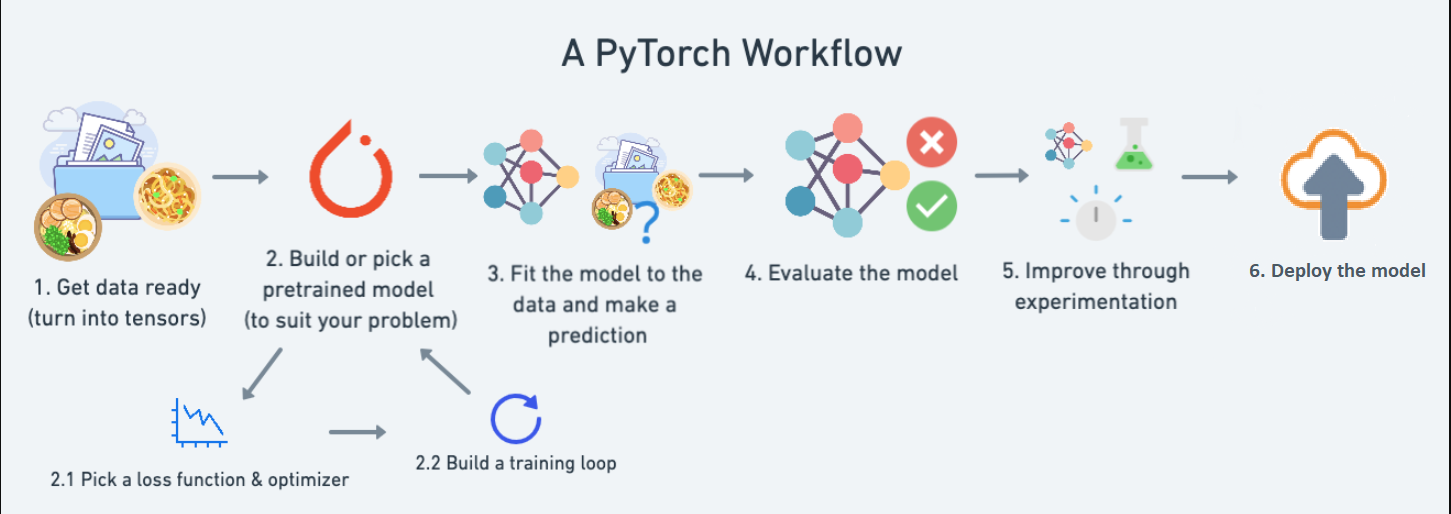

# **Import Libraries and Frameworks**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from datetime import datetime

# **Device configuration**

Before starting the project, check whether the gpu is available and, if you want to know the gpu you will use, use the second script for have the complete description of the gpu available

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
!nvidia-smi

# **Hyper-parameters**

**num_epochs:** This refers to the number of times the model will iterate over the entire training dataset during the training process. Each iteration over the entire dataset is called an epoch. Increasing the number of epochs can improve the performance of the model, but can also lead to overfitting if the model is trained for too long.

**batch_size:** This refers to the number of training examples used in each iteration of the training process. During training, the model updates its parameters based on the gradients computed from the loss function for each batch. A larger batch size can speed up the training process, but may require more memory and can make it harder for the model to generalize well to new data.

**learning_rate:** This refers to the rate at which the model updates its parameters during training. The learning rate determines how much the model adjusts its weights in response to the calculated error. A higher learning rate can speed up the training process, but may cause the model to overshoot the optimal weights and result in poor performance. A lower learning rate may slow down training, but may result in a more stable and accurate model.

In [ ]:
num_epochs = 5
batch_size = 8
learning_rate = 0.001

#**Tensor**

First, since we should normalize our images before feeding them to the model, we will define a transform function, and use "torchvision.transforms.Normalize" to **normalize** all of our images when we create the training and test data variables. 

The first transformation is ToTensor(), which converts the image into a PyTorch tensor. A **Tensor** is a multi-dimensional array, and it is the primary data structure used in PyTorch. By converting the image to a tensor, it can be easily processed by neural networks and other machine learning algorithms.

The second transformation is Normalize(), which normalizes the pixel values of the image to a range of [-1, 1]. This transformation takes two arguments: a mean and a standard deviation. The mean and standard deviation are used to calculate the normalization values for each channel (red, green, and blue) of the image. In this case, the mean is (0.5, 0.5, 0.5) and the standard deviation is also (0.5, 0.5, 0.5).

The normalization step is important because it can help improve the performance of machine learning algorithms by making the data more consistent and easier to work with.

In [ ]:
# Define the data transformation to be applied to the dataset
transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),  # Convert image to PyTorch tensor
    torchvision.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize pixel values to [-1, 1]
])

# **PT1: convert Dataset in Tensor**

Now we download our dataset, in case you have already a dataset you will import from drive or other sources. 

We use our transform function in the transform argument so that PyTorch will apply this to the entire dataset.

In [ ]:
# Load the CIFAR10 dataset from the specified root directory and apply the transformation
dataset = torchvision.datasets.CIFAR10(root='./dataset', download=True, transform=transform)

# Split the dataset into training and testing subsets using the train_test_split() function
train_dataset, test_dataset = train_test_split(dataset, test_size=0.25)

When working with a dataset, it is common to divide it into two parts: a training set and a test set. 

*   The training set is used to build the model, and it learns from the data provided in this set only. 
*   The test set is then used to evaluate the model's ability to generalize and make predictions on new, unseen data.

Alternatively, one can create a single combined dataset and use an external oracle to test the model's responses to new inputs. The typical split between training and test sets is:

**~80-90%** for training;

**~10-20%** for testing.

But this can vary depending on the size and nature of the dataset.

In [ ]:
print("number of elements in training set",len(train_dataset))
print("number of elements in test set",len(test_dataset))

number of elements in training set 37500
number of elements in test set 12500


# Extra

Sometimes we also need to tune the hyperparameters of our model, which are settings that control how the model learns from the data. To do this, we need a third set of data that is separate from both the training and testing sets, called the validation set. We can use this set to evaluate different hyperparameter settings and choose the best ones

# **Create DataLoaders**

A data loader is a PyTorch utility that can be used to load data from a dataset in batches. A data loader is typically used when training a neural network to feed the data to the network in mini-batches, which can help to improve the efficiency and accuracy of the training process.

In [ ]:
# Create a data loader for the training subset, using the DataLoader class from PyTorch
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Create a data loader for the testing subset, using the DataLoader class from PyTorch
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


# **Show images before train**

In [ ]:
# Define a function to display an image
def imshow(img):
    # Unnormalize the image by reversing the normalization transform applied earlier
    img = img / 2 + 0.5

    # Convert the PyTorch tensor to a NumPy array
    npimg = img.numpy()

    # Transpose the array to match the format expected by matplotlib
    npimg = np.transpose(npimg, (1, 2, 0))

    # Display the image using matplotlib
    plt.imshow(npimg)
    plt.show()


# Get a batch of random training images
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Display the images using the imshow function
imshow(torchvision.utils.make_grid(images))

#**PT 2: Model Training** 

# **Define Model Architecture**

Once the data has been collected and preprocessed, the next step is to design the architecture of the machine learning model. This involves selecting the appropriate layers and activation functions, and tuning the hyperparameters of the model.

In [ ]:
# Define a class for the CNN model
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        
        # Define the convolutional layers
        self.conv1 = nn.Conv2d(3, 6, 5)     # input channels=3, output channels=6, kernel size=5x5
        self.pool = nn.MaxPool2d(2, 2)      # max pooling layer with kernel size=2x2, stride=2
        self.conv2 = nn.Conv2d(6, 16, 5)    # input channels=6, output channels=16, kernel size=5x5
        
        # Define the fully connected layers
        self.fc1 = nn.Linear(16 * 5 * 5, 120) # input size=16x5x5, output size=120
        self.fc2 = nn.Linear(120, 84)         # input size=120, output size=84
        self.fc3 = nn.Linear(84, 10)          # input size=84, output size=10

    def forward(self, x):
        # Pass the input tensor through the layers of the network
        
        x = self.pool(F.relu(self.conv1(x)))  # Apply the first convolutional layer, ReLU activation, and max pooling
                                              # Output shape: (batch_size, 6, 14, 14)
        
        x = self.pool(F.relu(self.conv2(x)))  # Apply the second convolutional layer, ReLU activation, and max pooling
                                              # Output shape: (batch_size, 16, 5, 5)
        
        x = x.view(-1, 16 * 5 * 5)            # Flatten the tensor to a 1D vector
                                              # Output shape: (batch_size, 16 * 5 * 5)
        
        x = F.relu(self.fc1(x))               # Apply the first fully connected layer and ReLU activation
                                              # Output shape: (batch_size, 120)
        
        x = F.relu(self.fc2(x))               # Apply the second fully connected layer and ReLU activation
                                              # Output shape: (batch_size, 84)
        
        x = self.fc3(x)                       # Apply the third fully connected layer (no activation function)
                                              # Output shape: (batch_size, 10)
        
        return x

Once the model architecture has been defined, the next step is to train the model on the data. This involves selecting an appropriate optimization algorithm, defining the loss function, and training the model on the training data. 

Don't forget to train the model on gpu with ".to(device)" or write ".to('cuda')"

In [ ]:
# create an instance of the CNN class and move it to the specified device
model = CNN().to(device)

# define the loss function to be used during training
# cross-entropy loss is commonly used for multi-class classification problems like CIFAR-10
criterion = nn.CrossEntropyLoss()

# create an optimizer object that will be used to update the model parameters during training
# in this case, we're using stochastic gradient descent (SGD) with the specified learning rate
# the `model.parameters()` argument tells the optimizer which parameters to update (i.e. the weights and biases of the neural network)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

# **PT3: Fit the model to the data**

Once the model has been trained, it is important to evaluate its performance on a separate test dataset. This involves running the test data through the trained model and calculating metrics such as accuracy, precision, and recall

In [ ]:
# define the classes for the CIFAR-10 dataset
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

In [ ]:
# get the total number of steps (i.e. batches) in the training set
# we'll use this to keep track of the training progress
n_total_steps = len(train_loader)

# iterate over the specified number of epochs
for epoch in range(num_epochs):

    # iterate over the batches in the training data loader
    for i, (images, labels) in enumerate(train_loader):

        # move the input and target data to the specified device
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass: compute predicted outputs by passing inputs to the model
        outputs = model(images)

        # Compute the loss
        loss = criterion(outputs, labels)

        # Backward and optimize
        optimizer.zero_grad()       # zero the gradients
        loss.backward()             # compute the gradients
        optimizer.step()            # update the weights and biases

        # print training statistics every 2000 batches
        if (i+1) % 2000 == 0:
            print (f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{n_total_steps}], Loss: {loss.item():.4f}')

# print a message indicating that training has finished
print('Finished Training')

# save the trained model to a file
PATH = './cnn.pth'
torch.save(model.state_dict(), PATH)

# **PT4: Evaluate the model**

In [ ]:
with torch.no_grad():
    # initialize variables to keep track of accuracy
    n_correct = 0
    n_samples = 0
    n_class_correct = [0 for i in range(10)]
    n_class_samples = [0 for i in range(10)]
    
    # loop through test_loader to get predictions and calculate accuracy
    for images, labels in test_loader:
        # send images and labels to device
        images = images.to(device)
        labels = labels.to(device)
        
        # get predictions
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        # update accuracy variables
        n_samples += labels.size(0)
        n_correct += (predicted == labels).sum().item()
        
        # update class-wise accuracy variables
        for i in range(labels.size(0)):
            label = labels[i]
            pred = predicted[i]
            if (label == pred):
                n_class_correct[label] += 1
            n_class_samples[label] += 1

    # calculate and print overall accuracy
    acc = 100.0 * n_correct / n_samples
    print(f'Accuracy of the network: {acc} %')

    # calculate and print class-wise accuracy
    for i in range(10):
        acc = 100.0 * n_class_correct[i] / n_class_samples[i]
        print(f'Accuracy of {classes[i]}: {round(acc, 2)} %')

# **PT 5: Improve through experimentation**

In many cases, the performance of the model can be improved by tuning the hyperparameters of the model, such as the learning rate, batch size, and regularization strength. This involves running multiple experiments with different hyperparameters and selecting the set of hyperparameters that results in the best performance on the validation dataset.

In [ ]:
# Define a function to run a single experiment with a given set of hyperparameters
def run_experiment(lr, epochs):
    # Create a new instance of the neural network
    net = CNN()
    # Define the loss function
    criterion = nn.CrossEntropyLoss()
    # Define the optimizer with the given learning rate and momentum
    optimizer = torch.optim.SGD(net.parameters(), lr=lr, momentum=0.8)

    # Loop over the dataset for a fixed number of epochs
    for epoch in range(epochs):
        running_loss = 0.0
        # Loop over the batches in the dataset
        for i, data in enumerate(train_loader, 0):
            # Get the input and target tensors for the current batch
            inputs, labels = data
            # Zero the gradients
            optimizer.zero_grad()
            # Compute the output of the neural network for the current batch
            outputs = net(inputs)
            # Compute the loss between the output and the target
            loss = criterion(outputs, labels)
            # Compute the gradients using backpropagation
            loss.backward()
            # Update the parameters of the neural network using the optimizer
            optimizer.step()
            # Keep track of the running loss for the current epoch
            running_loss += loss.item()
    
    # Compute the accuracy of the neural network on the test set
    correct = 0
    total = 0
    with torch.no_grad():
        for data in test_loader:
            images, labels = data
            outputs = net(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    # Return the accuracy of the neural network
    return accuracy

# Define a set of hyperparameters to try
learning_rates = [0.01, 0.1, 1]
n_epochs = [1, 3, 5]

# Run multiple experiments with different hyperparameters
best_accuracy = 0
for lr in learning_rates:
    for epoch in n_epochs:
        start = datetime.now()
        # Run a single experiment with the current hyperparameters
        accuracy = run_experiment(lr, epoch)
        end = datetime.now()
        time= end - start
        # Print the hyperparameters and accuracy for the current experiment
        print(f"lr={lr}, epochs={epoch}, accuracy={accuracy}, training_time={time}")
        # If the current experiment has the highest accuracy so far, record the hyperparameters and accuracy
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_lr = lr
            best_epoch = epoch

# Print the hyperparameters and accuracy of the best experiment
print(f"*Best hyperparameters: lr={best_lr}, epoch={epoch}, accuracy={best_accuracy}*")

# **Convert this code for Tensorboard**

**Write in TensorBoard a few example of images**

In [ ]:
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter("cifar_images")

In [ ]:
img_grid=torchvision.utils.make_grid(images)
writer.add_image('cifar_images',img_grid)
writer.flush()

**Add the Neural Network in Tensorboard**

In [ ]:
# create an instance of the CNN class and move it to the specified device
model = CNN().to(device)

# define the loss function to be used during training
# cross-entropy loss is commonly used for multi-class classification problems like CIFAR-10
criterion = nn.CrossEntropyLoss()

# create an optimizer object that will be used to update the model parameters during training
# in this case, we're using stochastic gradient descent (SGD) with the specified learning rate
# the `model.parameters()` argument tells the optimizer which parameters to update (i.e. the weights and biases of the neural network)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

# move the input tensor to the same device as the model
images = images.to(device)

writer.add_graph(model,images)
writer.flush()

**Add loss and accuracy of DNN in Tensorboard**

In [ ]:
running_loss=0.0
running_correct=0
n_total_steps=len(train_loader)
# iterate over the specified number of epochs
for epoch in range(num_epochs):
    # iterate over the batches in the training data loader
    for i, (images, labels) in enumerate(train_loader):

        # move the input and target data to the specified device
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass: compute predicted outputs by passing inputs to the model
        outputs = model(images)

        # Compute the loss
        loss = criterion(outputs, labels)

        # Backward and optimize
        optimizer.zero_grad()       # zero the gradients
        loss.backward()             # compute the gradients
        optimizer.step()            # update the weights and biases

        running_loss+=loss.item()
        _, predicted = torch.max(outputs, 1)
        running_correct+=(predicted==labels).sum().item()
        # print training statistics every 2000 batches
        if (i+1) % 2000 == 0:
            print (f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{n_total_steps}], Loss: {loss.item():.4f}')
            writer.add_scalar('Training Loss',running_loss/100, epoch * n_total_steps+i)
            writer.add_scalar('Accuracy',running_correct/100, epoch * n_total_steps+i)
            running_loss=0.0
            running_correct=0
writer.flush()
writer.close()
# print a message indicating that training has finished
print('Finished Training')

# save the trained model to a file
PATH = './cnn.pth'
torch.save(model.state_dict(), PATH)

**Load and display Tensorboard** 

In [ ]:
%load_ext tensorboard
%reload_ext tensorboard
%tensorboard --logdir=cifar_images --port 6007

# **PT 6: Deployment**

Once the model has been trained and its hyperparameters have been tuned, it can be deployed for use in a production environment. This involves integrating the model into a larger software system and ensuring that it can handle new input data in a timely and accurate manner.

# **Extra Source**

I let you popular tutorial where you can learn and improve your skills developing a correct neural network with low effort 😊:


*   Intro to pytorch 1, Towards Data Science:https://towardsdatascience.com/intro-to-pytorch-part-1-663574fb9675
*   Deep Learning with Pytorch, Youtuber Patrick Loeber: https://www.youtube.com/watch?v=c36lUUr864M&ab_channel=PatrickLoeber
*  Pytorch Deep learning, Daniel Bourke Github:  https://github.com/mrdbourke/pytorch-deep-learning

* Tensoboard Playground: https://playground.tensorflow.org/

